# 05a — DeepLabV3+ (ResNet-50)

**Paper**: Mohammad et al. — *Deep Learning based Semantic Segmentation for Mars Rover Terrain Classification*  
DOI: `10.1109/iSpaRo60631.2024.10687827` — iSpaRo 2024  

**Arquitectura**: DeepLabV3+ con backbone ResNet-50 preentrenado en ImageNet, cabeza ASPP y cabeza auxiliar (weight=0.4).  
**Entrenamiento**: Google Colab Pro (A100 / T4 recomendado).

---

## Instrucciones de uso

### Prueba rapida en computador local (sin GPU potente)

Antes de lanzar el entrenamiento completo en Colab, verifica que el pipeline funciona en tu maquina local con `fast_subset=True`:

```python
# En la celda de configuracion, cambia:
FAST_SUBSET = True   # activa el subset pequeno (~200 imgs train, ~50 val)
```

Esto corre ~2 min por seed en CPU/RTX 4050 y verifica que no hay errores en el pipeline completo (carga de datos -> forward -> loss -> metricas -> checkpoint). Solo guarda el modelo del primer seed para no llenar disco.

**No uses** los resultados de `fast_subset=True` para el benchmark — son solo para depuracion.

### Entrenamiento completo en Google Colab Pro

1. Subir el proyecto a Google Drive en `/content/drive/MyDrive/ai4mars_DL-v3/`
2. Asegurarse de que `processed/split_indices_msl6k.pkl` este en el repo (no se regenera)
3. Montar Drive y ejecutar todas las celdas en orden
4. Los checkpoints se guardan en Drive automaticamente

## 0. Setup — Detectar entorno (Local vs Colab)

In [1]:
import os, sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    !git clone https://github.com/UnDauphin/ai4mars_DL-v3 /content/ai4mars_DL-v3
    !pip install torch==2.6.0 torchvision==0.21.0 --index-url https://download.pytorch.org/whl/cu124 -q
    !pip install -r /content/ai4mars_DL-v3/requirements.txt -q
    PROJECT_ROOT = Path('/content/ai4mars_DL-v3')
    sys.path.append(str(PROJECT_ROOT / 'notebooks'))
    import mars_utils
    mars_utils.CHECKPOINTS_DIR = Path('/content/drive/MyDrive/ai4mars_DL-v3/checkpoints')
    mars_utils.CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
    print('Colab — Drive montado, repo clonado, dependencias instaladas')
else:
    # Local: este notebook esta en notebooks/, ROOT es el padre
    PROJECT_ROOT = Path('__file__').resolve().parent.parent
    # Fallback si __file__ no funciona en Jupyter
    if not (PROJECT_ROOT / 'processed').exists():
        PROJECT_ROOT = Path.cwd().parent
    print(f'Local — ROOT: {PROJECT_ROOT}')

print(f'ROOT existe: {PROJECT_ROOT.exists()}')
print(f'processed/ existe: {(PROJECT_ROOT / "processed").exists()}')
print(f'data/ existe: {(PROJECT_ROOT / "data").exists()}')

Local — ROOT: C:\Users\User\Documents\DeepLearning\ai4mars_DL-v3
ROOT existe: True
processed/ existe: True
data/ existe: True


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from mars_utils import (
    set_seed, load_norm_stats, load_split,
    build_dataloaders, MetricsAccumulator,
    train_one_epoch, evaluate, train_model, run_multi_seed,
    append_benchmark_results, plot_best_seed_curves,
    print_summary_table, visualize_predictions, count_parameters,
    NUM_CLASSES, IGNORE_INDEX, SEEDS,
    CHECKPOINTS_DIR, BENCHMARK_CSV
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
VRAM: 6.4 GB


## 1. Configuracion

In [3]:
# ======================================================
#  CONFIGURACION — ajustar segun entorno
# ======================================================

MODEL_NAME   = 'DeepLabV3+'
FAST_SUBSET  = True   # True para prueba rapida local; False para produccion en Colab

# Hiperparametros (segun KB seccion 9.1)
LR           = 0.001
MOMENTUM     = 0.9
WEIGHT_DECAY = 1e-4
AUX_WEIGHT   = 0.4
MAX_EPOCHS   = 80
PATIENCE     = 10     # KB v6: patience subido de 7 a 10
BATCH_SIZE   = 16

# Pesos de clase: soil=1.0, bedrock=0.8, sand=2.0, big_rock=8.0
CLASS_WEIGHTS = torch.tensor([1.0, 0.8, 2.0, 8.0], dtype=torch.float32).to(DEVICE)

print(f'Modo: {"FAST SUBSET (prueba)" if FAST_SUBSET else "PRODUCCION COMPLETA"}')
print(f'Epochs max: {MAX_EPOCHS} | Early stopping patience: {PATIENCE}')
print(f'Seeds: {SEEDS}')

Modo: FAST SUBSET (prueba)
Epochs max: 80 | Early stopping patience: 10
Seeds: [42, 123, 7]


## 2. Datos

In [4]:
df_train, df_val, df_gold = load_split()
mean, std = load_norm_stats()

print(f'Train: {len(df_train)} | Val: {len(df_val)} | Gold test: {len(df_gold)}')
print(f'Normalizacion — mean: {mean} | std: {std}')

✅ Split cargado — train: 4200 | val: 1800 | gold test: 322
Train: 4200 | Val: 1800 | Gold test: 322
Normalizacion — mean: [0.2303263779898021, 0.2303263779898021, 0.2303263779898021] | std: [0.10591342097577364, 0.10591342097577364, 0.10591342097577364]


In [5]:
# Verificacion anti data leakage
# Bug 6: derivar stem de image_path — df_train['stem'] no existe
train_ids = set(Path(p).stem for p in df_train['image_path'])
gold_ids  = set(Path(p).stem for p in df_gold['image_path'])
assert len(train_ids & gold_ids) == 0, 'DATA LEAKAGE: overlap entre train y gold test'
print(f'Sin overlap entre train y gold test')
print(f'Train: {len(df_train)} | Val: {len(df_val)} | Gold: {len(df_gold)}')

Sin overlap entre train y gold test
Train: 4200 | Val: 1800 | Gold: 322


## 3. Arquitectura — DeepLabV3+ con ResNet-50

In [13]:
class DeepLabV3PlusMars(nn.Module):
    """
    DeepLabV3+ con backbone ResNet-50 preentrenado en ImageNet.
    - Salida principal: cabeza ASPP -> 4 clases
    - Salida auxiliar:  cabeza aux sobre layer3 -> 4 clases (weight=0.4 en loss)
    - Entrada esperada: [B, 3, 256, 256]
    - Salida en inferencia: [B, 4, 256, 256]

    Referencia: Mohammad et al., iSpaRo 2024.
    """
    def __init__(self, num_classes: int = 4, aux_loss: bool = True):
        super().__init__()
        self.aux_loss = aux_loss

        # Carga DeepLabV3 con ResNet-50 preentrenado y ajusta la cabeza final
        weights = DeepLabV3_ResNet50_Weights.DEFAULT
        base = deeplabv3_resnet50(weights=weights, aux_loss=aux_loss)

        # Reemplazar cabeza principal (256 canales ASPP -> num_classes)
        base.classifier[-1] = nn.Conv2d(256, num_classes, kernel_size=1)

        # Reemplazar cabeza auxiliar (256 -> num_classes)
        if aux_loss and base.aux_classifier is not None:
            base.aux_classifier[-1] = nn.Conv2d(256, num_classes, kernel_size=1)

        self.model = base

    def forward(self, x):
        h, w = x.shape[-2:]
        out = self.model(x)

        # Upsample a resolucion original si es necesario
        logits = F.interpolate(out['out'], size=(h, w),
                               mode='bilinear', align_corners=False)

        if self.training and self.aux_loss and 'aux' in out:
            aux_logits = F.interpolate(out['aux'], size=(h, w),
                                       mode='bilinear', align_corners=False)
            return {'out': logits,'aux': aux_logits}
        return {'out': logits}

def build_model():
    return DeepLabV3PlusMars(num_classes=NUM_CLASSES, aux_loss=True).to(DEVICE)


# Verificacion rapida de shapes
_m = build_model()
_m.eval()
with torch.no_grad():
    _x = torch.randn(2, 3, 256, 256).to(DEVICE)
    _out = _m(_x)
    print(f'Forward OK — salida eval: {_out["out"].shape}')   # (2, 4, 256, 256)

_m.train()
with torch.no_grad():
    _out_train = _m(_x)
    print(f'Forward OK — salida train: logits={_out_train["out"].shape}, aux={_out_train["aux"].shape}')

n_params = count_parameters(_m)
print(f'Parametros entrenables: {n_params:.2f}M  (referencia KB: ~42.00M)')
del _m, _x, _out, _out_train

Forward OK — salida eval: torch.Size([2, 4, 256, 256])
Forward OK — salida train: logits=torch.Size([2, 4, 256, 256]), aux=torch.Size([2, 4, 256, 256])
Parametros entrenables: 42.00M  (referencia KB: ~42.00M)


## 4. Loss, Optimizer y Scheduler

In [14]:
class DeepLabLoss(nn.Module):
    """
    CrossEntropyLoss con class weights e ignore_index.
    En entrenamiento combina salida principal + cabeza auxiliar (weight=0.4).
    En evaluacion solo usa la salida principal.
    """
    def __init__(self, weight: torch.Tensor, aux_weight: float = 0.4,
                 ignore_index: int = 255):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=weight, ignore_index=ignore_index)
        self.aux_weight = aux_weight

    def forward(self, output, target):
        if isinstance(output, dict):
            logits = output['out']
            loss_main = self.ce(logits, target)

            if 'aux' in output:
                loss_aux = self.ce(output['aux'], target)
                return loss_main + self.aux_weight * loss_aux

            return loss_main

        return self.ce(output, target)


def criterion_fn():
    return DeepLabLoss(
        weight=CLASS_WEIGHTS,
        aux_weight=AUX_WEIGHT,
        ignore_index=IGNORE_INDEX
    )


def optimizer_fn(params):
    return torch.optim.SGD(
        params, lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY
    )


def scheduler_fn(optimizer):
    # PolynomialLR: lr decae con potencia 0.9 a lo largo de MAX_EPOCHS iteraciones
    return torch.optim.lr_scheduler.PolynomialLR(
        optimizer, total_iters=MAX_EPOCHS, power=0.9
    )


print('Loss, optimizer y scheduler definidos')
print(f'  Loss: CrossEntropyLoss (weights=[1.0, 0.8, 2.0, 8.0], aux_weight={AUX_WEIGHT})')
print(f'  Optimizer: SGD (lr={LR}, momentum={MOMENTUM}, wd={WEIGHT_DECAY})')
print(f'  Scheduler: PolynomialLR (power=0.9, {MAX_EPOCHS} iters)')

Loss, optimizer y scheduler definidos
  Loss: CrossEntropyLoss (weights=[1.0, 0.8, 2.0, 8.0], aux_weight=0.4)
  Optimizer: SGD (lr=0.001, momentum=0.9, wd=0.0001)
  Scheduler: PolynomialLR (power=0.9, 80 iters)


## 5. Entrenamiento Multi-Seed

**Nota Colab**: Los checkpoints se guardan en `ROOT/checkpoints/` que apunta a Google Drive.  
**Nota local** con `FAST_SUBSET=True`: ~200 imgs train, ~50 val, ~2 min/seed — solo para verificar el pipeline.

In [15]:
print(f"df_train shape: {df_train.shape}")
print(f"df_val shape:   {df_val.shape}")
print(f"df_gold shape:  {df_gold.shape}")
print()
print("Primeras rutas de df_train:")
print(df_train['image_path'].head(3).tolist())
print()
# Verificar que los archivos realmente existen
from pathlib import Path
sample = df_train['image_path'].iloc[0] if len(df_train) > 0 else "VACÍO"
print(f"Primer archivo existe: {Path(sample).exists() if sample != 'VACÍO' else 'df_train está vacío'}")

df_train shape: (4200, 6)
df_val shape:   (1800, 6)
df_gold shape:  (322, 6)

Primeras rutas de df_train:
['C:\\Users\\User\\Documents\\DeepLearning\\ai4mars_DL-v3\\data\\images_256\\NLA_397681801EDR_F0020000AUT_04096M1.jpg', 'C:\\Users\\User\\Documents\\DeepLearning\\ai4mars_DL-v3\\data\\images_256\\NLA_397681867EDR_F0020000AUT_04096M1.jpg', 'C:\\Users\\User\\Documents\\DeepLearning\\ai4mars_DL-v3\\data\\images_256\\NLA_397681893EDR_F0020000AUT_04096M1.jpg']

Primer archivo existe: True


In [16]:
import pickle
from pathlib import Path

# Ver qué hay dentro del pickle
PROCESSED_DIR = Path(PROJECT_ROOT) / 'processed'
with open(PROCESSED_DIR / 'split_indices_msl6k.pkl', 'rb') as f:
    split = pickle.load(f)

print("Claves del pickle:", list(split.keys()))
print("Tipo de train_ids:", type(list(split.values())[0]))
print("Primeros 3 elementos de train_ids:", list(split.values())[0][:3])
print("Total train_ids:", len(list(split.values())[0]))

Claves del pickle: ['train_ids', 'val_ids', 'seed', 'n_subset', 'val_ratio', 'stratify_col']
Tipo de train_ids: <class 'list'>
Primeros 3 elementos de train_ids: ['NLB_550542471EDR_F0633326NCAM00353M1', 'NLB_450326513EDR_F0310538NCAM00350M1', 'NLB_574253980EDR_F0681816NCAM00259M1']
Total train_ids: 4200


In [17]:
# Ver qué tiene el manifest y cómo se ven sus stems
import pandas as pd
manifest = pd.read_csv(PROCESSED_DIR / 'manifest_msl_train.csv')
print("Columnas del manifest:", manifest.columns.tolist())
print("Primera ruta de imagen:", manifest['image_path'].iloc[0])
print("Stem de esa ruta:", Path(manifest['image_path'].iloc[0]).stem)
print("Primer train_id del pickle:", list(split.values())[0][0])

Columnas del manifest: ['mission', 'camera', 'id', 'image_path', 'mask_path', 'split']
Primera ruta de imagen: msl\ncam\images\edr\NLA_397681339EDR_F0020000AUT_04096M1.JPG
Stem de esa ruta: NLA_397681339EDR_F0020000AUT_04096M1
Primer train_id del pickle: NLB_550542471EDR_F0633326NCAM00353M1


In [18]:
# Bug 7: run_multi_seed NO acepta mean, std ni max_epochs.
# El parametro correcto es num_epochs. mean/std los carga internamente.
summary = run_multi_seed(
    model_fn       = build_model,
    df_train       = df_train,
    df_val         = df_val,
    df_gold        = df_gold,
    criterion_fn   = criterion_fn,
    optimizer_fn   = optimizer_fn,
    scheduler_fn   = scheduler_fn,
    model_name     = MODEL_NAME,
    device         = DEVICE,
    num_epochs     = MAX_EPOCHS,   # 'num_epochs', no 'max_epochs'
    patience       = PATIENCE,
    batch_size     = BATCH_SIZE,
    fast_subset    = FAST_SUBSET,
    n_train_fast   = 200,
    n_val_fast     = 50,
)


───────────────────────────────────────────────────────
  Seed 42 | DeepLabV3+
⚡ Subset rápido — train: 200 | val: 50
   (Para entrenamiento real usar df_train y df_val completos)
  Entrenamiento desde cero

  DeepLabV3+_seed42 | device=cuda | AMP=True
  epochs=80 | patience=10 | aux_weight=0.0
Ep   1/80 | loss=1.3155 mIoU=0.2004 | val_loss=1.2122 val_mIoU=0.2204 | rock=0.0092
Ep   2/80 | loss=1.1225 mIoU=0.3500 | val_loss=1.0038 val_mIoU=0.3330 | rock=0.0000
Ep   3/80 | loss=0.9674 mIoU=0.3844 | val_loss=0.8281 val_mIoU=0.3622 | rock=0.0000
Checkpoint periódico guardado (epoch 3)
Ep   4/80 | loss=0.8324 mIoU=0.3923 | val_loss=0.7411 val_mIoU=0.3759 | rock=0.0000
Ep   5/80 | loss=0.7845 mIoU=0.4109 | val_loss=0.6842 val_mIoU=0.4108 | rock=0.0000
Ep   6/80 | loss=0.7041 mIoU=0.4588 | val_loss=0.6256 val_mIoU=0.4526 | rock=0.1085
Checkpoint periódico guardado (epoch 6)
Ep   7/80 | loss=0.6699 mIoU=0.4976 | val_loss=0.5735 val_mIoU=0.5008 | rock=0.1256
Ep   8/80 | loss=0.5780 mIoU=0.6284

## 6. Resultados Agregados

In [19]:
print_summary_table(summary)


  RESUMEN — DeepLabV3+
  Métrica                 Media       Std      IC95
  ------------------------------------------------
  mIoU                   0.6703    0.0024  ± 0.0028
  Pixel Accuracy         0.9383
  ------------------------------------------------
  IoU soil               0.9271    0.0053
  IoU bedrock            0.8360    0.0049
  IoU sand               0.8687    0.0247
  IoU big_rock           0.0492    0.0244
  ------------------------------------------------
  Params (M)           —
  Tiempo medio (s)          531
  Epoch mejor (mean)       33.7



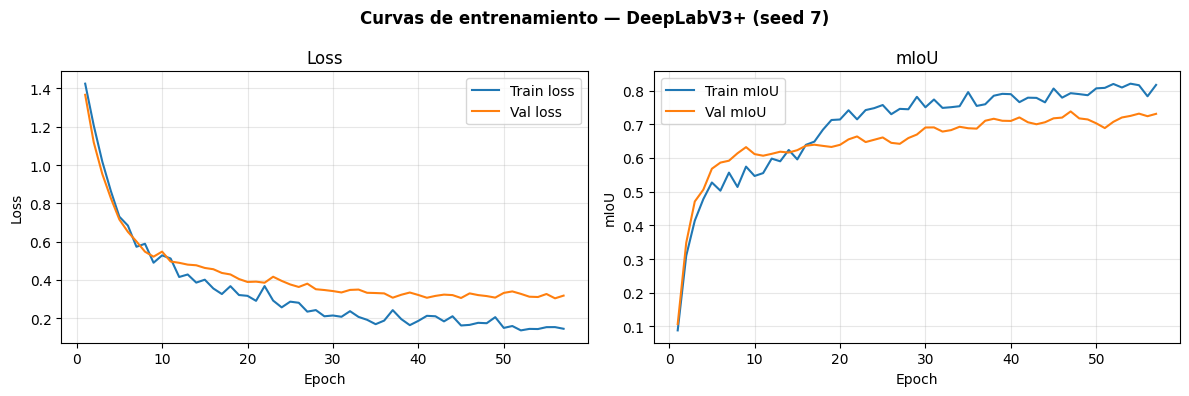

In [20]:
plot_best_seed_curves(summary)

In [21]:
# Bug 9: limpiar fila anterior del mismo modelo antes de guardar,
# para evitar duplicados si se reejecutar el notebook.
if BENCHMARK_CSV.exists():
    df_csv = pd.read_csv(BENCHMARK_CSV)
    df_csv = df_csv[df_csv['model'] != MODEL_NAME]
    df_csv.to_csv(BENCHMARK_CSV, index=False)

params_M = count_parameters(build_model())
append_benchmark_results(summary, params_M=params_M)
print(f'Resultados guardados en results/benchmark_results.csv')

Resultados guardados en C:\Users\User\Documents\DeepLearning\ai4mars_DL-v3\results\benchmark_results.csv
Resultados guardados en results/benchmark_results.csv


## 7. Visualizacion Cualitativa

5 ejemplos del gold set: imagen original | ground truth | prediccion del mejor seed.

Mejor seed: 7 | mIoU gold: 0.6732


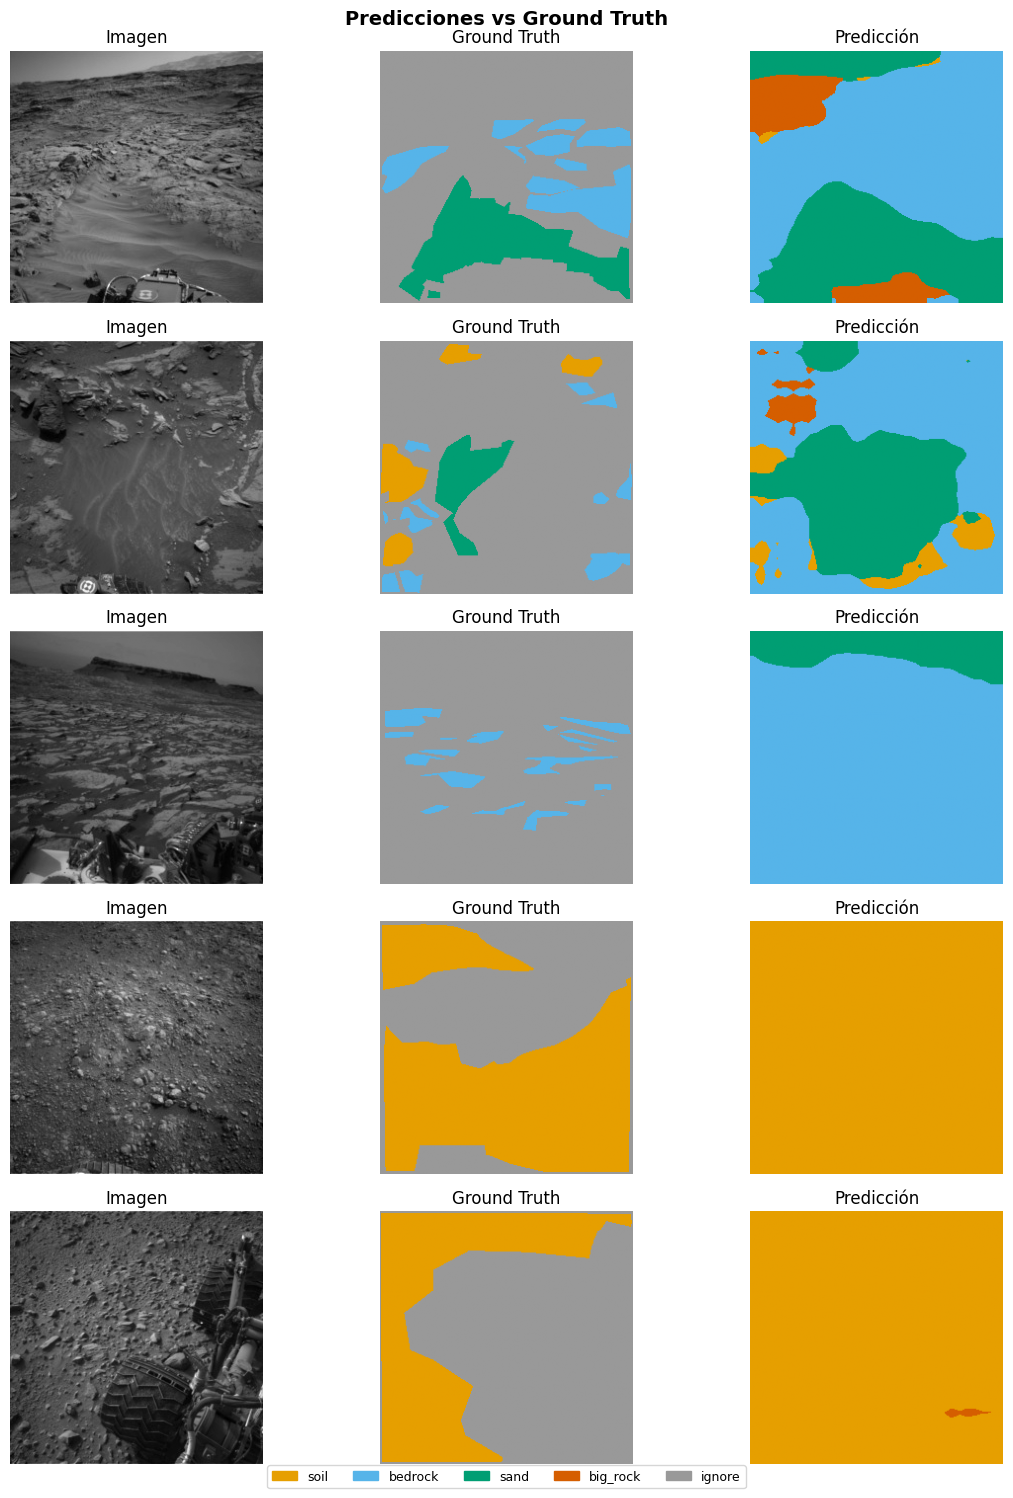

In [24]:
# Bug 8: summary no tiene clave 'best_seed' ni 'checkpoints'.
# Extraer best_seed manualmente desde summary['per_seed'].
best_seed = max(summary['per_seed'], key=lambda r: r['mIoU'])['seed']
ckpt_path = CHECKPOINTS_DIR / f'{MODEL_NAME}_seed{best_seed}_best.pth'

best_model = build_model()
ckpt = torch.load(ckpt_path, map_location=DEVICE)
best_model.load_state_dict(ckpt['model_state'])
best_model.eval()

best_miou = max(summary['per_seed'], key=lambda r: r['mIoU'])['mIoU']
print(f'Mejor seed: {best_seed} | mIoU gold: {best_miou:.4f}')

visualize_predictions(
    model  = best_model,
    df_gold= df_gold,
    device = DEVICE,
    mean   = mean,
    std    = std,
    n      = 5
)

## 8. Resumen Final

| Campo | Valor |
|-------|-------|
| Modelo | DeepLabV3+ (ResNet-50) |
| Paper | Mohammad et al., iSpaRo 2024 |
| Backbone | ResNet-50 preentrenado ImageNet |
| Loss | CrossEntropyLoss + aux head (w=0.4) |
| Optimizer | SGD (lr=0.001, momentum=0.9) |
| Scheduler | PolynomialLR (power=0.9) |
| Referencia historica (2.1k imgs) | mIoU = 0.6806 +/- 0.0107 |

---
*Los resultados definitivos del gold set se exportaron a `results/benchmark_results.csv`.*